### 🤖 What are Multi-Agent RAG Systems?
A Multi-Agent RAG System splits the RAG pipeline into multiple specialized agents — each responsible for a specific role — and enables them to collaborate on a single query or task.

#### 1. 📋 Multi-Agent Network RAG System with LangGraph
Project Overview

A beginner-friendly Retrieval-Augmented Generation (RAG) system that uses a multi-agent architecture to intelligently answer questions from your documents. Built with LangGraph v0.3 for workflow orchestration and OpenAI for language understanding.

What It Does

Transforms your documents (PDFs, text files) into a searchable knowledge base that can answer questions intelligently using AI. Simply upload documents and ask questions in natural language - the system finds relevant information and generates comprehensive answers.
Key Features

- 📚 Multi-Format Support: Handles PDF and text documents
- 🤖 3-Agent Architecture: Specialized agents for document processing, retrieval, and answer generation
- 🔍 Smart Search: Vector-based semantic search finds relevant information
- 💬 Natural Language Q&A: Ask questions in plain English


In [1]:
from langchain.chat_models import init_chat_model
from langchain_ollama import OllamaEmbeddings
embeddings=OllamaEmbeddings(model="llama3.2:latest")
llm=init_chat_model("ollama:llama3.2:latest")
llm

ChatOllama(model='llama3.2:latest')

In [2]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_classic.tools import WikipediaQueryRun
from langchain_classic.utilities import WikipediaAPIWrapper
from langchain_classic.document_loaders import TextLoader
from langchain_classic.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

tavily_tool=TavilySearch(max_results=5, api_key=os.getenv("TAVILY_API_KEY"))

In [4]:
from langchain_core.tools import Tool
def make_retriever_tool_from_text(file,name,desc):
    docs=TextLoader(file, encoding='utf-8').load()
    chunks=RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vs=FAISS.from_documents(chunks,embeddings)
    retriever=vs.as_retriever()

    def tool_func(querry:str):
        print(f"🔍 {name} retriever tool invoked...")
        result=retriever.invoke(querry)
        return "\n\n".join(doc.page_content for doc in result)
    
    return Tool(func=tool_func, name=name, description=desc)

internal_tool_1=make_retriever_tool_from_text("research_notes.txt","Internal Research Notes Retriever","Useful for answering questions about the research notes. Always use this for questions related to the research notes.")

In [5]:
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.types import Command

def get_next_node(last_message:BaseMessage, goto:str):
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto


In [6]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

### Research Agent

C:\Users\ArnavBhatia\AppData\Local\Temp\ipykernel_29172\1173372584.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent=create_react_agent(model=llm, tools=[internal_tool_1,tavily_tool],prompt=make_system_prompt("You can only do research. Use the tool that you are binded with, you can use both of them" \


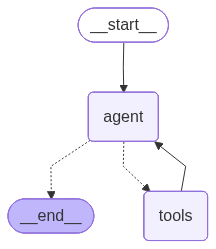

In [7]:
research_agent=create_react_agent(model=llm, tools=[internal_tool_1,tavily_tool],prompt=make_system_prompt("You can only do research. Use the tool that you are binded with, you can use both of them" \
    " You are working with a content writer colleague.")
    )
research_agent

Research Node

In [8]:
from typing import Literal
def research_node(state:MessagesState)-> Command[Literal["blog_generation",END]]:
    result=research_agent.invoke({"messages": state["messages"]})
    goto=get_next_node(state["messages"][-1], "blog_generation")
    result['messages'][-1]=HumanMessage(content=result['messages'][-1].content,name="researcher")
    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )


### Blog Writer Agent

In [9]:
### Blog write agent
blog_agent=create_react_agent(
    llm,
    tools=[],
    prompt=make_system_prompt(
        "You can only write a detailed blog. You are working with a researcher colleague."
    )
)


C:\Users\ArnavBhatia\AppData\Local\Temp\ipykernel_29172\428261172.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  blog_agent=create_react_agent(


In [10]:
def blog_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = blog_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="blog_generator"
    )
    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

## Graph

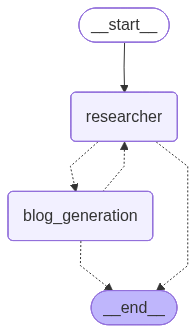

In [11]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("blog_generation", blog_node)
workflow.add_edge(START, "researcher")
graph=workflow.compile()
graph

In [12]:
response=graph.invoke({"messages": [HumanMessage(content="Write a detailed blog on transformer variants in production deployments")]})

In [13]:
response["messages"][-1].content

'FINAL ANSWER\n\nBased on the search results provided, it appears that there are several resources available that discuss transformer variants and their use in production deployments. However, none of these resources provide a single, definitive final answer.\n\nThe search results include articles and blog posts that discuss the use of specific transformer variants, such as BERT, GPT, T5, and LLaMA, in production environments for text summarization and other tasks. These resources provide valuable insights into the capabilities and limitations of these variants, but do not offer a single, overarching answer.\n\nSimilarly, the search results include articles that discuss attention transformers variants and their optimization for specific constraints, such as sequence length, memory, and latency. While these resources provide useful information on the design and deployment of transformer variants, they do not offer a definitive final answer.\n\nThe search results also include resources t

### Multi Agent Suprvisor With RAG
Supervisor is a multi-agent architecture where specialized agents are coordinated by a central supervisor agent. The supervisor agent controls all communication flow and task delegation, making decisions about which agent to invoke based on the current context and task requirements.

In this tutorial, you will build a supervisor system with two agents — a research and a math expert. By the end of the tutorial you will:

1. Build specialized research and math agents
2. Build a supervisor for orchestrating them with the prebuilt langgraph-supervisor
3. Build a supervisor 
4. Implement advanced task delegation


In [14]:
internal_tool_1

Tool(name='Internal Research Notes Retriever', description='Useful for answering questions about the research notes. Always use this for questions related to the research notes.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000002A7948311C0>)

In [15]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(max_results=3)
web_search

TavilySearch(max_results=3, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

C:\Users\ArnavBhatia\AppData\Local\Temp\ipykernel_29172\1701589918.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent=create_react_agent(


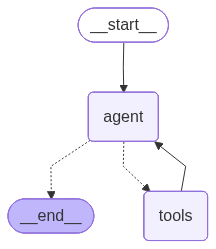

In [16]:
from langgraph.prebuilt import create_react_agent

research_agent=create_react_agent(
    model=llm,
    tools=[web_search,internal_tool_1],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent"
)
research_agent

In [17]:
def add(a: float, b: float):
    """Add two numbers."""
    return a + b


def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b


def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b


math_agent=create_react_agent(
    model=llm,
    tools=[add,multiply,divide],
    prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent"

)

C:\Users\ArnavBhatia\AppData\Local\Temp\ipykernel_29172\3915409306.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  math_agent=create_react_agent(


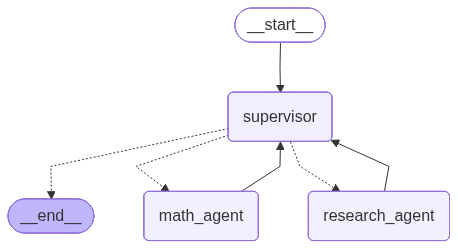

In [19]:
### create supervisor agent

from langgraph_supervisor import create_supervisor
supervisor=create_supervisor(
    model=llm,
    agents=[research_agent,math_agent],
    prompt=(
         "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."

    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
).compile()

supervisor

In [26]:
response=supervisor.invoke({"messages":" list all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10"})

In [27]:
response

{'messages': [HumanMessage(content=' list all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10', additional_kwargs={}, response_metadata={}, id='0b107b87-49db-4408-ae09-fe4965af8917'),
  AIMessage(content='{"name": "get_transformer_variants", "parameters": {"retriever": "True"}} \n{"name": "add", "parameters": {"x": "5", "y": "10"}}', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-30T18:37:01.0883455Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1127318100, 'load_duration': 370503500, 'prompt_eval_count': 248, 'prompt_eval_duration': 229850100, 'eval_count': 44, 'eval_duration': 479190900, 'model_name': 'llama3.2:latest'}, name='supervisor', id='lc_run--019ddfae-10b3-7020-bfa8-d45b08a19aea-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 248, 'output_tokens': 44, 'total_tokens': 292})]}

In [28]:
response["messages"][-1].content

'{"name": "get_transformer_variants", "parameters": {"retriever": "True"}} \n{"name": "add", "parameters": {"x": "5", "y": "10"}}'